In [47]:
%load_ext autoreload
%autoreload 2

from blochK import Hamiltonian2D
from blochK.plotting import plot_bandstruc, plot_FS
from blochK.observable import conductivity_orbital_resolved

import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


array([[[ 0.81927427, -0.17342714],
        [-0.17342714,  0.36386971]],

       [[ 0.81927427,  0.17342714],
        [ 0.17342714,  0.36386971]]])

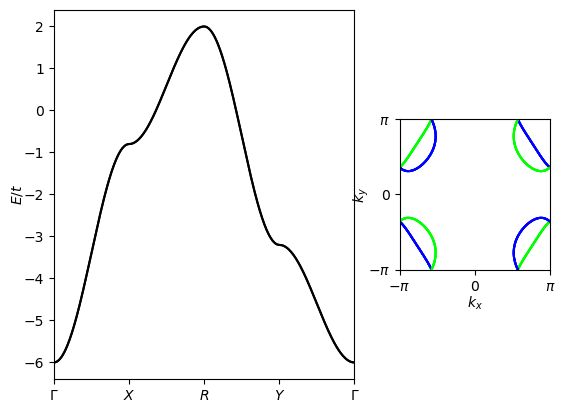

In [60]:
def Htilt_fct(kx,ky,t1=1,d1=0,t2=0,d2=0,t4=0,d4=0,mu=0):

    Hk = np.zeros((2,2,*kx.shape),dtype=complex)

    Hk[0,0] = -2*(t1+d1)*cos(kx) - 2*(t1-d1)*cos(ky) -mu 
    Hk[0,0] += -2*(t2+d2)*cos(kx+ky) -2*(t2-d2)*cos(kx-ky)
    Hk[0,0] += - 2*(t4+d4)*cos(2*kx+ky) - 2*(t4-d4)*cos(2*kx-ky) #- 2*(t4-d4)*cos(kx+2*ky) - 2*(t4+d4)*cos(kx-2*ky)

    Hk[1,1] = -2*(t1+d1)*cos(kx) - 2*(t1-d1)*cos(ky) -mu 
    Hk[1,1] += -2*(t2-d2)*cos(kx+ky) -2*(t2+d2)*cos(kx-ky)
    Hk[1,1] += - 2*(t4-d4)*cos(2*kx+ky) - 2*(t4+d4)*cos(2*kx-ky) #- 2*(t4-d4)*cos(kx+2*ky) - 2*(t4+d4)*cos(kx-2*ky)
    return Hk

H = Hamiltonian2D(Htilt_fct)
H.add_operator('spin',np.array([1,-1]))




fig, axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]})


H.set_params(dict(d2=0.3,d1=0.3,mu=2))
plot_bandstruc(axs[0],H)
plot_FS(axs[1],H,coloring_operator=H.operator.spin)

conductivity_orbital_resolved(H)